### Astrostatistic Lecture 17

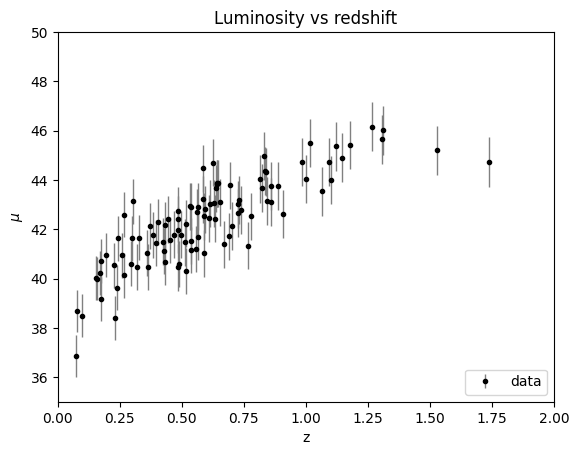

In [6]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
import numpy as np
from tqdm import tqdm
from scipy import stats

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50);

39.60456481105869 [4.5911933]


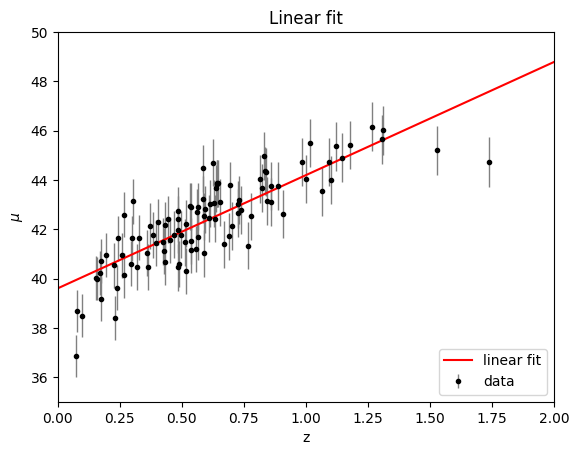

In [7]:
#first we try a linear regression
z_sample=z_sample.reshape(-1,1)

lin_reg = LinearRegression()
lin_reg.fit(z_sample, mu_sample, sample_weight = dmu)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

test_z = np.linspace(0,2,100)
test_mu = theta0 + theta1*test_z

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(test_z, test_mu, 'r', label='linear fit')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Linear fit")
plt.xlim(0,2)
plt.ylim(35,50);

polynomial coefficients for 3 degrees: [38.36452837  8.87820312 -3.06677777  0.17557977]
polynomial coefficients for 4 degrees: [ 36.95622821  21.50098389 -34.55444621  28.77101798  -8.39275909]
polynomial coefficients for 5 degrees: [ 36.09081526  32.02899002 -73.25156852  87.69138092 -47.26697125
   9.15349892]
polynomial coefficients for 6 degrees: [  35.38164335   43.1313125  -128.73943257  210.2480827  -179.32235517
   76.99221964  -13.2572731 ]
polynomial coefficients for 7 degrees: [   33.07559304    87.7120308   -415.17424944  1058.97570095
 -1489.07605606  1161.10280616  -468.28719026    75.87210529]
polynomial coefficients for 8 degrees: [  33.56005026   76.71142746 -328.6942935   732.80233282 -817.31111329
  366.63790671   68.65384194 -116.42734486   28.24788153]
polynomial coefficients for 9 degrees: [   35.1828307     34.56226168    66.26161979 -1105.24083702
  4019.93828695 -7274.00893435  7437.12480885 -4355.02416849
  1361.51277085  -176.16638799]


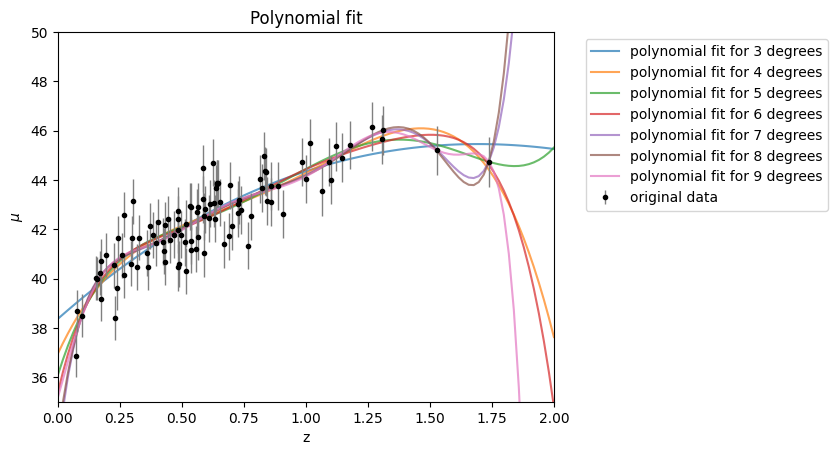

I bet on the 3rd degree or maybe a 4th degree


In [8]:
#polynomial fit 
z_sample=z_sample.reshape(-1,1)
for deg in range(3,10):

    pol_reg = PolynomialRegression(degree=deg)
    pol_reg.fit(z_sample, mu_sample, dmu)
    
    print(f'polynomial coefficients for {deg} degrees: {pol_reg.coef_}')
    
    test_z = np.linspace(0,2,100)
    test_mu = pol_reg.predict(test_z.reshape(-1,1))
    
    
    plt.plot(test_z, test_mu, label=f'polynomial fit for {deg} degrees', alpha=0.7)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='original data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Polynomial fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()
print('I bet on the 3rd degree or maybe a 4th degree')


Polynomial of degree: 3
Train error: 0.9192095775613319
Test error: 0.8455839781565544

Polynomial of degree: 4
Train error: 0.8912375642360254
Test error: 0.7973377641955992

Polynomial of degree: 5
Train error: 0.8900785720968463
Test error: 0.7724063355389613

Polynomial of degree: 6
Train error: 0.8654079793417644
Test error: 1.2133988927951194

Polynomial of degree: 7
Train error: 0.8555884670281799
Test error: 0.8784287773395422

Polynomial of degree: 8
Train error: 0.8537763602083228
Test error: 1.6626553073370216

Polynomial of degree: 9
Train error: 0.8537373819287473
Test error: 2.036825040979327


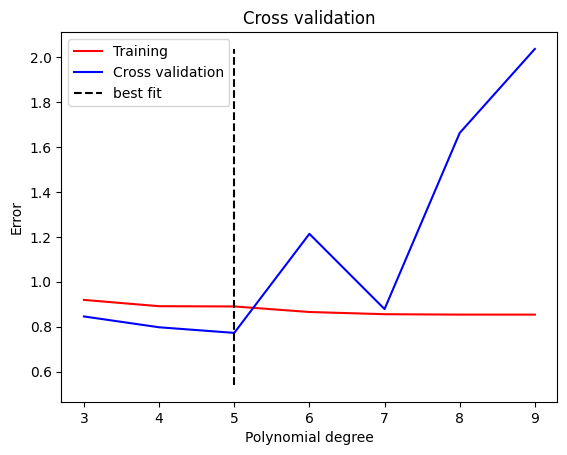

In [10]:
from sklearn.model_selection import train_test_split

#now we can make a cross validation of the polynomial fit
train=[]
test=[]

X_train, X_test, y_train, y_test = train_test_split(z_sample, mu_sample, test_size=0.2, random_state=420)    #split the sample

for deg in range(3,10):
    print(f'\nPolynomial of degree: {deg}')
    pol_reg = PolynomialRegression(degree=deg)
    pol_reg.fit(X_train, y_train)

    y_pred = pol_reg.predict(X_test)
    train_Err = np.sqrt(np.sum((pol_reg.predict(X_train) - y_train) ** 2)/ len(y_train))
    train.append(train_Err)
    print(f'Train error: {train_Err}')

    test_err = np.sqrt(np.sum((y_pred - y_test) ** 2)/ len(y_pred))
    test.append(test_err)
    print(f'Test error: {test_err}')


plt.plot(range(3,10), train, label='Training', color="#FF0000",)
plt.plot(range(3,10), test, label='Cross validation', color='#0000FF')
plt.vlines(3+np.argmin(test), min(test)*0.7, max(test), linestyles='--', color='#000000', label='best fit')
plt.xlabel('Polynomial degree')
plt.ylabel('Error')
plt.title('Cross validation')
plt.legend()
plt.show()

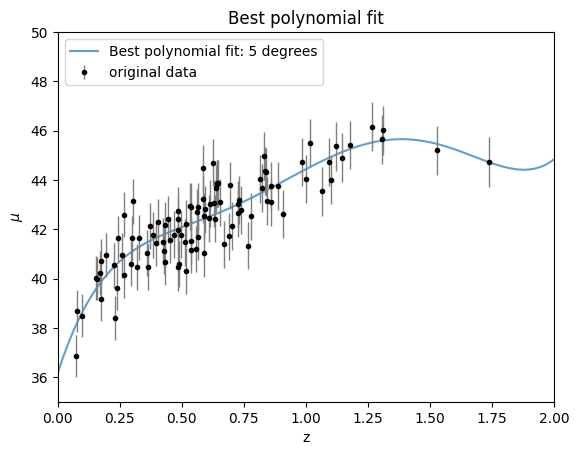

My bet was off :'(


In [5]:
pol_reg = PolynomialRegression(degree=3+np.argmin(test))
pol_reg.fit(z_sample, mu_sample)

test_z = np.linspace(0,2,100)
test_mu = pol_reg.predict(test_z.reshape(-1,1))


plt.plot(test_z, test_mu, label=f'Best polynomial fit: 5 degrees', alpha=0.7)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='original data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='upper left')
plt.title("Best polynomial fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()
print('My bet was off :\'(')